# EDA Completo — PetFinder Adoption Prediction

**Dataset:** PetFinder Malaysia (Kaggle)  
**Objetivo:** Análisis exploratorio exhaustivo del dataset de adopción de mascotas para entender los factores que influyen en la velocidad de adopción (`AdoptionSpeed`).

---

## Sección 0 — Setup y Carga de Datos

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import os
import json
import warnings
from wordcloud import WordCloud

warnings.filterwarnings('ignore')

# Estilo global de gráficos
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

# Paleta consistente para AdoptionSpeed
SPEED_COLORS = {0: '#2ecc71', 1: '#27ae60', 2: '#f39c12', 3: '#e67e22', 4: '#e74c3c'}
SPEED_LABELS = {0: '0-Mismo día', 1: '1-1ª semana', 2: '2-1er mes', 3: '3-2-3 meses', 4: '4-Sin adopción'}
SPEED_PALETTE = [SPEED_COLORS[i] for i in sorted(SPEED_COLORS)]

BASE_PATH = '../input/petfinder-adoption-prediction'
print('Librerías importadas correctamente.')

Librerías importadas correctamente.


In [2]:
# ── Carga de datasets principales ──────────────────────────────────────
train = pd.read_csv(f'{BASE_PATH}/train/train.csv')
breed_labels = pd.read_csv(f'{BASE_PATH}/breed_labels.csv')
color_labels = pd.read_csv(f'{BASE_PATH}/color_labels.csv')
state_labels = pd.read_csv(f'{BASE_PATH}/state_labels.csv')

print(f'Train shape: {train.shape}')
print(f'Breed labels: {breed_labels.shape}')
print(f'Color labels: {color_labels.shape}')
print(f'State labels: {state_labels.shape}')

Train shape: (14993, 24)
Breed labels: (307, 3)
Color labels: (7, 2)
State labels: (15, 2)


In [3]:
# ── Decodificaciones y features derivadas ──────────────────────────────

# Tipo de animal
train['Type_name'] = train['Type'].map({1: 'Perro', 2: 'Gato'})

# Razas
breed_map = breed_labels.set_index('BreedID')['BreedName'].to_dict()
train['Breed1_name'] = train['Breed1'].map(breed_map).fillna('Desconocida')

# Colores
color_map = color_labels.set_index('ColorID')['ColorName'].to_dict()
train['Color1_name'] = train['Color1'].map(color_map).fillna('Desconocido')

# Estados
state_map = state_labels.set_index('StateID')['StateName'].to_dict()
train['State_name'] = train['State'].map(state_map).fillna('Desconocido')

# Género
train['Gender_name'] = train['Gender'].map({1: 'Macho', 2: 'Hembra', 3: 'Mixto'})

# Vacunación / Desparasitación / Esterilización
ynu_map = {1: 'Sí', 2: 'No', 3: 'No sabe'}
train['Vaccinated_name'] = train['Vaccinated'].map(ynu_map)
train['Dewormed_name']   = train['Dewormed'].map(ynu_map)
train['Sterilized_name'] = train['Sterilized'].map(ynu_map)

# Salud
train['Health_name']       = train['Health'].map({1: 'Saludable', 2: 'Lesión menor', 3: 'Lesión grave'})
train['MaturitySize_name'] = train['MaturitySize'].map({1: 'Pequeño', 2: 'Mediano', 3: 'Grande', 4: 'Extra grande', 0: 'No aplica'})
train['FurLength_name']    = train['FurLength'].map({1: 'Corto', 2: 'Mediano', 3: 'Largo', 0: 'No aplica'})

# ── Features derivadas ────────────────────────────────────────────────
train['Tiene_nombre'] = train['Name'].apply(
    lambda x: False if (pd.isna(x) or str(x).strip().lower() in ['no name', 'no name yet']) else True
)
train['Desc_len_words'] = train['Description'].fillna('').apply(lambda x: len(str(x).split()))
train['PhotoAmt']       = train['PhotoAmt'].astype(int)

# Grupos de fotos
def photo_group(n):
    if n == 0:    return '0 fotos'
    elif n <= 3:  return '1-3'
    elif n <= 7:  return '4-7'
    else:         return '8+'
train['photo_group'] = train['PhotoAmt'].apply(photo_group)

# Health score
train['health_score'] = (
    (train['Vaccinated'] == 1).astype(int) +
    (train['Dewormed']   == 1).astype(int) +
    (train['Sterilized'] == 1).astype(int) +
    (train['Health']     == 1).astype(int)
)

# Etiqueta legible para AdoptionSpeed
train['Speed_label'] = train['AdoptionSpeed'].map(SPEED_LABELS)

print('Decodificaciones y features derivadas creadas correctamente.')

Decodificaciones y features derivadas creadas correctamente.


In [4]:
# ── Carga de JSONs de sentimiento ──────────────────────────────────────
sentiment_path = f'{BASE_PATH}/train_sentiment'
records = []

if os.path.isdir(sentiment_path):
    for fname in os.listdir(sentiment_path):
        if fname.endswith('.json'):
            pet_id = fname.replace('.json', '')
            try:
                with open(os.path.join(sentiment_path, fname), 'r', encoding='utf-8') as f:
                    data = json.load(f)
                ds = data.get('documentSentiment', {})
                records.append({
                    'PetID'              : pet_id,
                    'sent_score'         : ds.get('score', np.nan),
                    'sent_magnitude'     : ds.get('magnitude', np.nan),
                    'sent_num_sentences' : len(data.get('sentences', [])),
                    'sent_num_entities'  : len(data.get('entities', [])),
                })
            except Exception as e:
                pass  # Ignorar archivos corruptos

if records:
    sent_df = pd.DataFrame(records)
    train   = train.merge(sent_df, on='PetID', how='left')
    print(f'Sentimiento cargado: {len(records)} archivos JSON procesados.')
else:
    for col in ['sent_score', 'sent_magnitude', 'sent_num_sentences', 'sent_num_entities']:
        train[col] = np.nan
    print('No se encontraron JSONs de sentimiento. Columnas creadas con NaN.')

print(f'\nShape final del dataset: {train.shape}')

Sentimiento cargado: 14442 archivos JSON procesados.

Shape final del dataset: (14993, 44)


In [6]:
# Vista general del dataset
print(f'Shape: {train.shape}')
print(f'\nDTypes:')
print(train.dtypes)
train.head(3)

Shape: (14993, 44)

DTypes:
Type                    int64
Name                   object
Age                     int64
Breed1                  int64
Breed2                  int64
Gender                  int64
Color1                  int64
Color2                  int64
Color3                  int64
MaturitySize            int64
FurLength               int64
Vaccinated              int64
Dewormed                int64
Sterilized              int64
Health                  int64
Quantity                int64
Fee                     int64
State                   int64
RescuerID              object
VideoAmt                int64
Description            object
PetID                  object
PhotoAmt                int32
AdoptionSpeed           int64
Type_name              object
Breed1_name            object
Color1_name            object
State_name             object
Gender_name            object
Vaccinated_name        object
Dewormed_name          object
Sterilized_name        object
Health_name 

,Type,Name,Age,Breed1,Breed2,Gender,Color1,Color2,Color3,MaturitySize,...,FurLength_name,Tiene_nombre,Desc_len_words,photo_group,health_score,Speed_label,sent_score,sent_magnitude,sent_num_sentences,sent_num_entities
0,2,Nibble,3,299,0,1,1,7,0,1,...,Corto,True,69,1-3,1,2-1er mes,0.3,2.4,6.0,13.0
1,2,No Name Yet,1,265,0,1,1,2,0,2,...,Mediano,False,23,1-3,1,0-Mismo día,-0.2,0.7,2.0,2.0
2,1,Brisco,1,307,0,1,2,7,0,2,...,Mediano,True,69,4-7,3,3-2-3 meses,0.2,3.7,7.0,13.0


---
## Sección 1 — Calidad de Datos

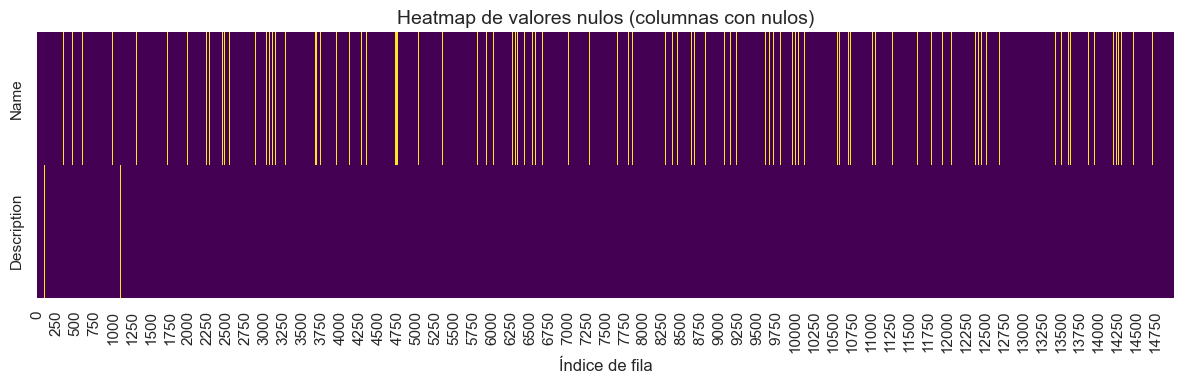

In [7]:
# ── Heatmap de nulos ───────────────────────────────────────────────────
# Solo columnas del dataset original con valores nulos
original_cols = [c for c in train.columns if '_name' not in c and c not in
                 ['Speed_label','Tiene_nombre','Desc_len_words','photo_group','health_score',
                  'sent_score','sent_magnitude','sent_num_sentences','sent_num_entities']]
null_cols = [c for c in original_cols if train[c].isnull().any()]

if null_cols:
    fig, ax = plt.subplots(figsize=(12, 4))
    sns.heatmap(
        train[null_cols].isnull().T,
        cbar=False,
        yticklabels=True,
        ax=ax,
        cmap='viridis'
    )
    ax.set_title('Heatmap de valores nulos (columnas con nulos)', fontsize=14)
    ax.set_xlabel('Índice de fila')
    plt.tight_layout()
    plt.show()
else:
    print('No hay columnas con valores nulos en el dataset original.')

In [8]:
# ── Tabla resumen de calidad ───────────────────────────────────────────
summary = pd.DataFrame({
    'Columna'     : original_cols,
    'Tipo'        : [train[c].dtype for c in original_cols],
    '% Nulos'     : [(train[c].isnull().mean() * 100).round(2) for c in original_cols],
    'Cardinalidad': [train[c].nunique() for c in original_cols],
})
summary.sort_values('% Nulos', ascending=False)

,Columna,Tipo,% Nulos,Cardinalidad
1,Name,object,8.44,9059
20,Description,object,0.09,14031
0,Type,int64,0.00,2
22,PhotoAmt,int32,0.00,31
21,PetID,object,0.00,14993
19,VideoAmt,int64,0.00,9
18,RescuerID,object,0.00,5595
17,State,int64,0.00,14
16,Fee,int64,0.00,74
15,Quantity,int64,0.00,19


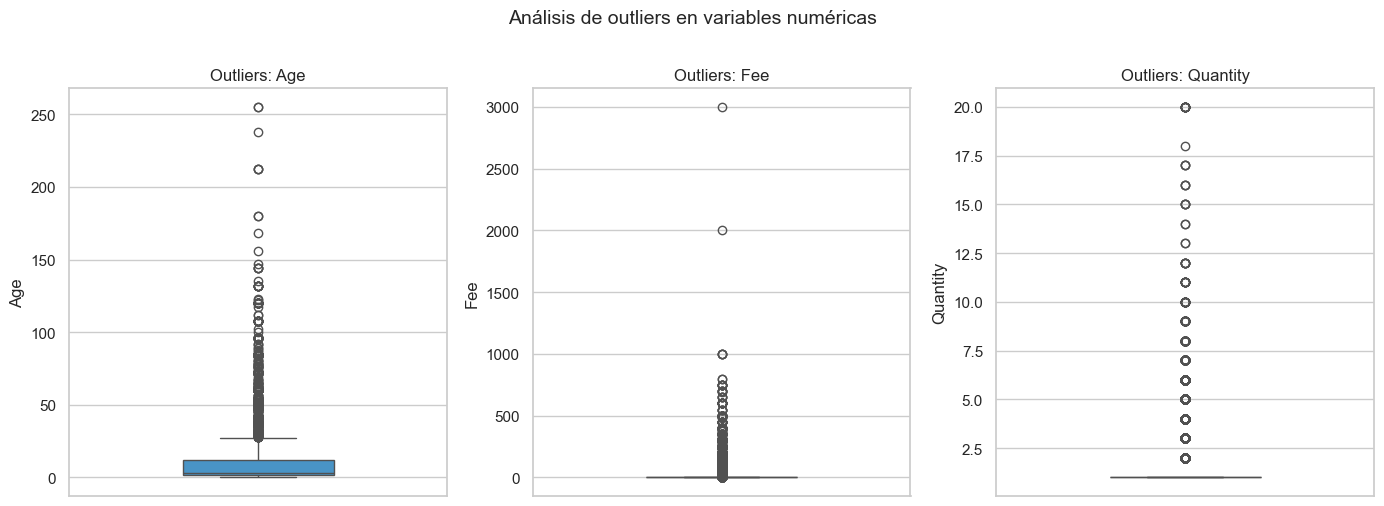

In [9]:
# ── Boxplots de outliers: Age, Fee, Quantity ────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, col in zip(axes, ['Age', 'Fee', 'Quantity']):
    sns.boxplot(y=train[col], ax=ax, color='#3498db', width=0.4)
    ax.set_title(f'Outliers: {col}', fontsize=12)
    ax.set_ylabel(col)

plt.suptitle('Análisis de outliers en variables numéricas', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### Interpretación — Calidad de Datos

- **Age**: presenta valores extremos de hasta **255 meses** (~21 años), lo cual es biológicamente improbable. La mayor parte de la distribución se concentra por debajo de los 60 meses.
- **Fee**: algunos registros tienen fee de hasta **3000 RM**, aunque la mayoría son adopciones gratuitas. Esta variable presenta una distribución muy sesgada hacia la derecha.
- **PhotoAmt**: puede aparecer como float en versiones antiguas del dataset; lo hemos convertido a int. Los valores van de 0 a 30+.
- Las columnas con mayor porcentaje de nulos son **Name** y **Description**, lo cual es esperable dado que no todos los anunciantes completan estos campos.

---
## Sección 2 — Variable Target: AdoptionSpeed

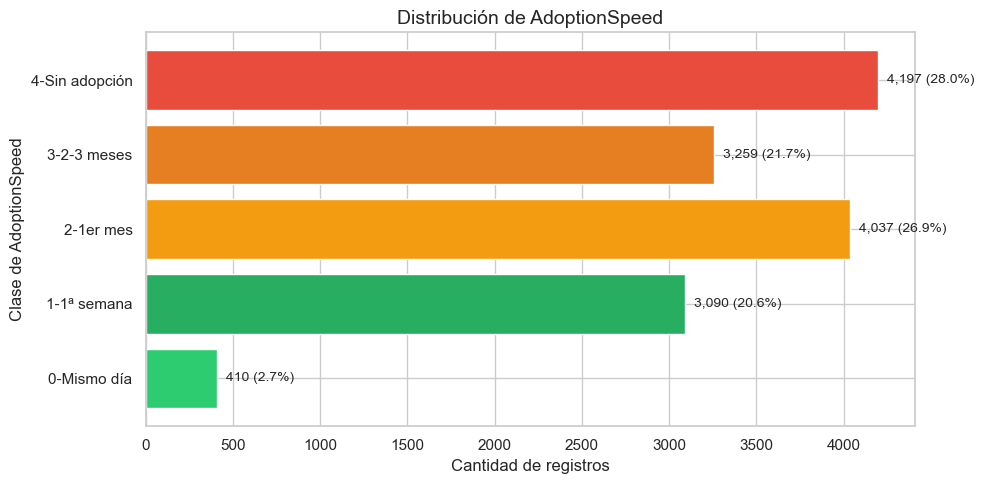

In [5]:
# ── Barplot horizontal de distribución de AdoptionSpeed ────────────────
speed_counts = train['AdoptionSpeed'].value_counts().sort_index()
speed_pct    = (speed_counts / speed_counts.sum() * 100).round(1)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(
    [SPEED_LABELS[i] for i in speed_counts.index],
    speed_counts.values,
    color=[SPEED_COLORS[i] for i in speed_counts.index],
    edgecolor='white'
)

# Etiquetas de conteo y porcentaje
for bar, count, pct in zip(bars, speed_counts.values, speed_pct.values):
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height() / 2,
            f'{count:,} ({pct}%)', va='center', fontsize=10)

ax.set_title('Distribución de AdoptionSpeed', fontsize=14)
ax.set_xlabel('Cantidad de registros')
ax.set_ylabel('Clase de AdoptionSpeed')
plt.tight_layout()
plt.show()

In [10]:
# ── Tabla de conteo y porcentaje ───────────────────────────────────────
target_table = pd.DataFrame({
    'Clase'      : [SPEED_LABELS[i] for i in speed_counts.index],
    'Conteo'     : speed_counts.values,
    '% del total': speed_pct.values
})
target_table

,Clase,Conteo,% del total
0,0-Mismo día,410,2.7
1,1-1ª semana,3090,20.6
2,2-1er mes,4037,26.9
3,3-2-3 meses,3259,21.7
4,4-Sin adopción,4197,28.0


### Interpretación — AdoptionSpeed

El target presenta un **claro desequilibrio de clases**:
- La clase **4 ("Sin adopción")** es la más frecuente con aproximadamente el **28%** de los registros.
- La clase **0 ("Mismo día")** es la más rara con apenas un **~2.7%**, lo que indica que las adopciones inmediatas son excepcionales.
- Las clases intermedias (1, 2, 3) tienen distribuciones más uniformes.

Este desequilibrio deberá tenerse en cuenta al entrenar modelos predictivos (técnicas de oversampling, pesos de clase, métricas específicas como F1-macro).

---
## Sección 3 — Tipo de Animal: Perros vs Gatos

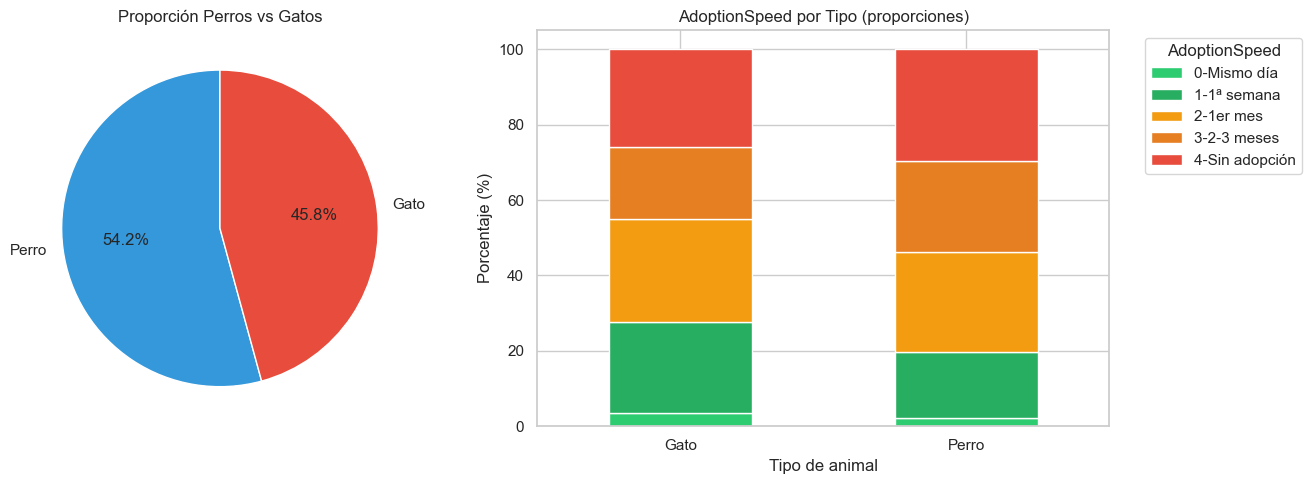

In [11]:
# ── Pie chart y barplot apilado normalizado ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
type_counts = train['Type_name'].value_counts()
axes[0].pie(
    type_counts.values,
    labels=type_counts.index,
    autopct='%1.1f%%',
    colors=['#3498db', '#e74c3c'],
    startangle=90
)
axes[0].set_title('Proporción Perros vs Gatos', fontsize=12)

# Barplot apilado normalizado: AdoptionSpeed por Type
cross = pd.crosstab(train['Type_name'], train['AdoptionSpeed'], normalize='index') * 100
cross.plot(
    kind='bar',
    stacked=True,
    ax=axes[1],
    color=SPEED_PALETTE,
    edgecolor='white'
)
axes[1].set_title('AdoptionSpeed por Tipo (proporciones)', fontsize=12)
axes[1].set_xlabel('Tipo de animal')
axes[1].set_ylabel('Porcentaje (%)')
axes[1].legend([SPEED_LABELS[i] for i in range(5)], title='AdoptionSpeed', bbox_to_anchor=(1.05, 1))
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

In [12]:
# AdoptionSpeed promedio por tipo
print('AdoptionSpeed promedio por tipo de animal:')
print(train.groupby('Type_name')['AdoptionSpeed'].mean().round(3))

AdoptionSpeed promedio por tipo de animal:
Type_name
Gato     2.400
Perro    2.615
Name: AdoptionSpeed, dtype: float64


### Interpretación — Perros vs Gatos

- Los **perros son ligeramente más frecuentes** que los gatos en el dataset.
- En cuanto a la velocidad de adopción, se observa que los **perros tienden a ser adoptados algo más rápido** en promedio (menor valor de AdoptionSpeed) que los gatos.
- Los gatos presentan mayor proporción en la clase 4 ("Sin adopción"), lo que indica que les cuesta más encontrar hogar.

---
## Sección 4 — Demografía: Edad, Género, Raza

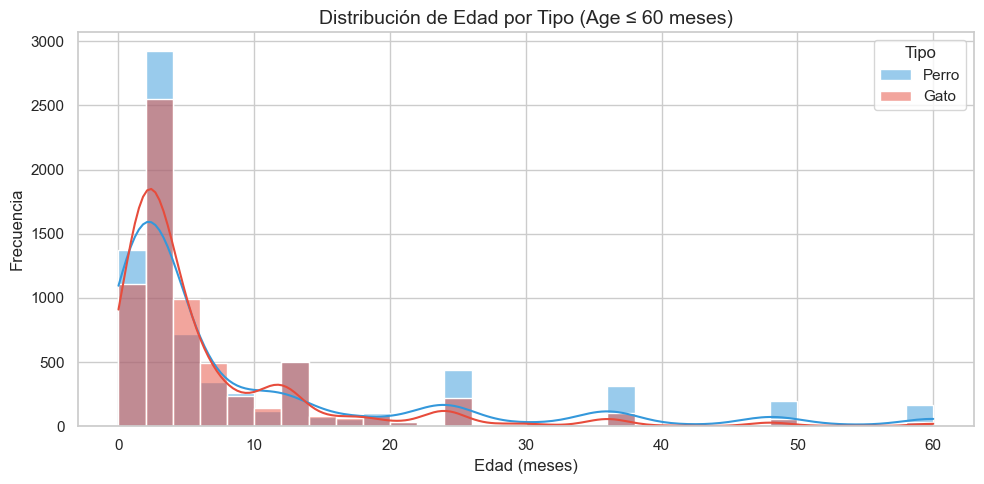

Nota: se excluyen 392 registros con Age > 60 meses para mejor visualización.


In [13]:
# ── Histograma de Age por Type con KDE overlay ─────────────────────────
df_age = train[train['Age'] <= 60].copy()

fig, ax = plt.subplots(figsize=(10, 5))
for tipo, color in [('Perro', '#3498db'), ('Gato', '#e74c3c')]:
    data = df_age.loc[df_age['Type_name'] == tipo, 'Age']
    sns.histplot(data, bins=30, kde=True, ax=ax, color=color, alpha=0.5, label=tipo)

ax.set_title('Distribución de Edad por Tipo (Age ≤ 60 meses)', fontsize=14)
ax.set_xlabel('Edad (meses)')
ax.set_ylabel('Frecuencia')
ax.legend(title='Tipo')
plt.tight_layout()
plt.show()
print(f'Nota: se excluyen {(train["Age"] > 60).sum()} registros con Age > 60 meses para mejor visualización.')

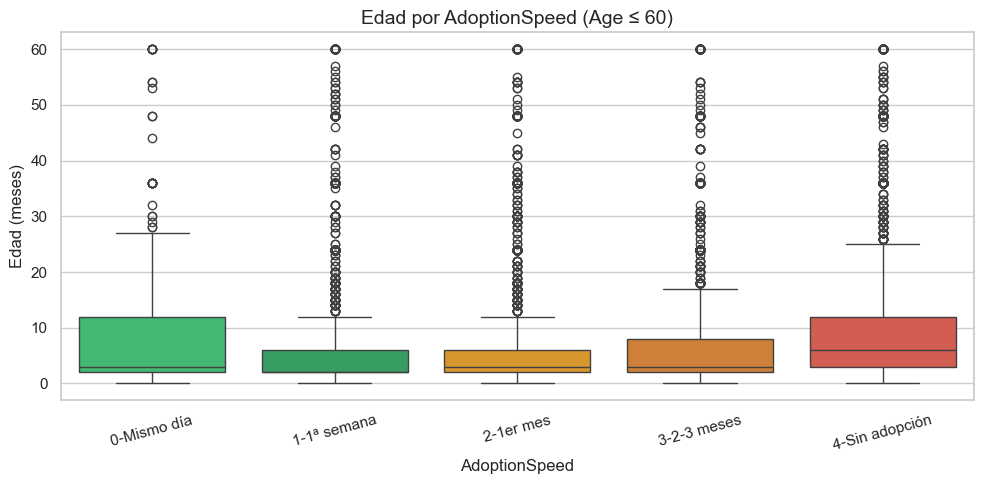

In [14]:
# ── Boxplot de Age por AdoptionSpeed ──────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(
    data=train[train['Age'] <= 60],
    x='AdoptionSpeed',
    y='Age',
    palette=SPEED_PALETTE,
    ax=ax
)
ax.set_title('Edad por AdoptionSpeed (Age ≤ 60)', fontsize=14)
ax.set_xlabel('AdoptionSpeed')
ax.set_ylabel('Edad (meses)')
ax.set_xticklabels([SPEED_LABELS[i] for i in range(5)], rotation=15)
plt.tight_layout()
plt.show()

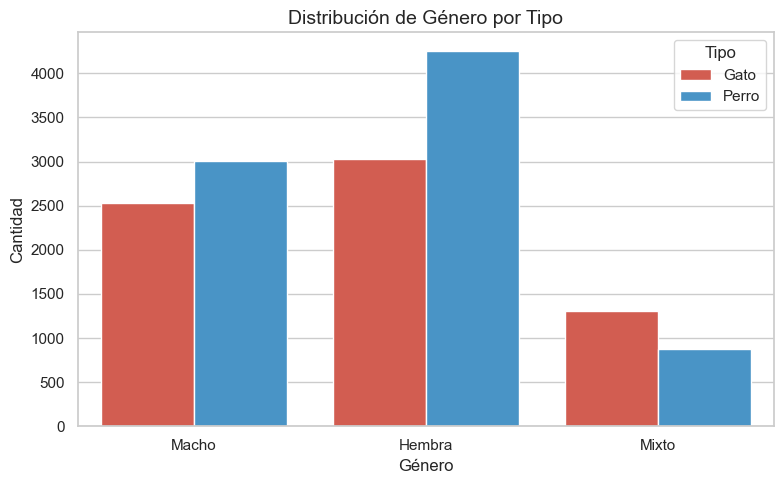

In [15]:
# ── Countplot de Gender por Type ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(
    data=train,
    x='Gender_name',
    hue='Type_name',
    palette={'Perro': '#3498db', 'Gato': '#e74c3c'},
    ax=ax
)
ax.set_title('Distribución de Género por Tipo', fontsize=14)
ax.set_xlabel('Género')
ax.set_ylabel('Cantidad')
ax.legend(title='Tipo')
plt.tight_layout()
plt.show()

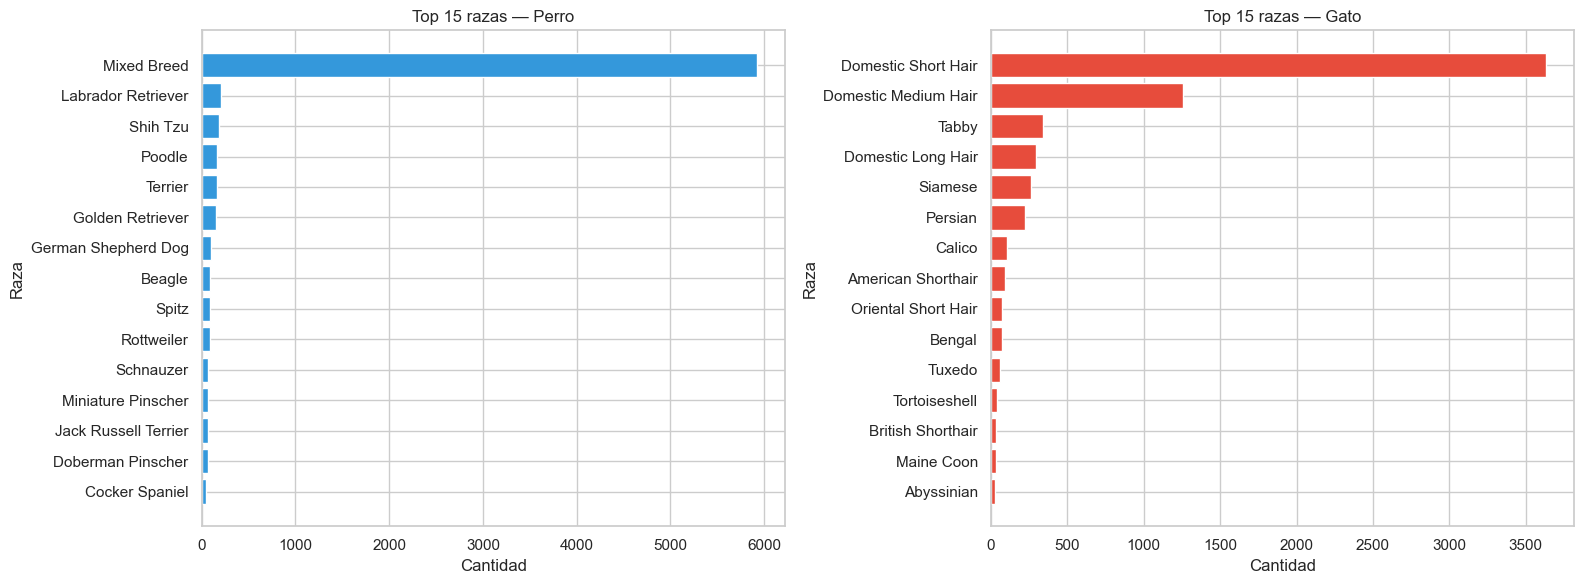

Proporción de mascotas con raza mixta (Breed2 > 0): 28.2%


In [16]:
# ── Top 15 razas primarias separadas por Type ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, tipo in zip(axes, ['Perro', 'Gato']):
    top_breeds = (
        train[train['Type_name'] == tipo]['Breed1_name']
        .value_counts()
        .head(15)
    )
    ax.barh(top_breeds.index[::-1], top_breeds.values[::-1],
            color='#3498db' if tipo == 'Perro' else '#e74c3c')
    ax.set_title(f'Top 15 razas — {tipo}', fontsize=12)
    ax.set_xlabel('Cantidad')
    ax.set_ylabel('Raza')

plt.tight_layout()
plt.show()

# Proporción con raza mixta
pct_mixta = (train['Breed2'] > 0).mean() * 100
print(f'Proporción de mascotas con raza mixta (Breed2 > 0): {pct_mixta:.1f}%')

### Interpretación — Demografía

- **Edad**: Los cachorros/gatitos jóvenes (0–6 meses) son los más comunes en el dataset. Las mascotas más jóvenes tienden a tener velocidades de adopción más rápidas.
- **Género**: Los machos son ligeramente más frecuentes que las hembras tanto en perros como en gatos. El género mixto aparece en listings grupales.
- **Razas**: La raza más común en perros es el Mestizo, seguido de razas populares locales. En gatos domina el "Domestic Short Hair". Un porcentaje significativo de mascotas tiene raza mixta.

---
## Sección 5 — Características Físicas

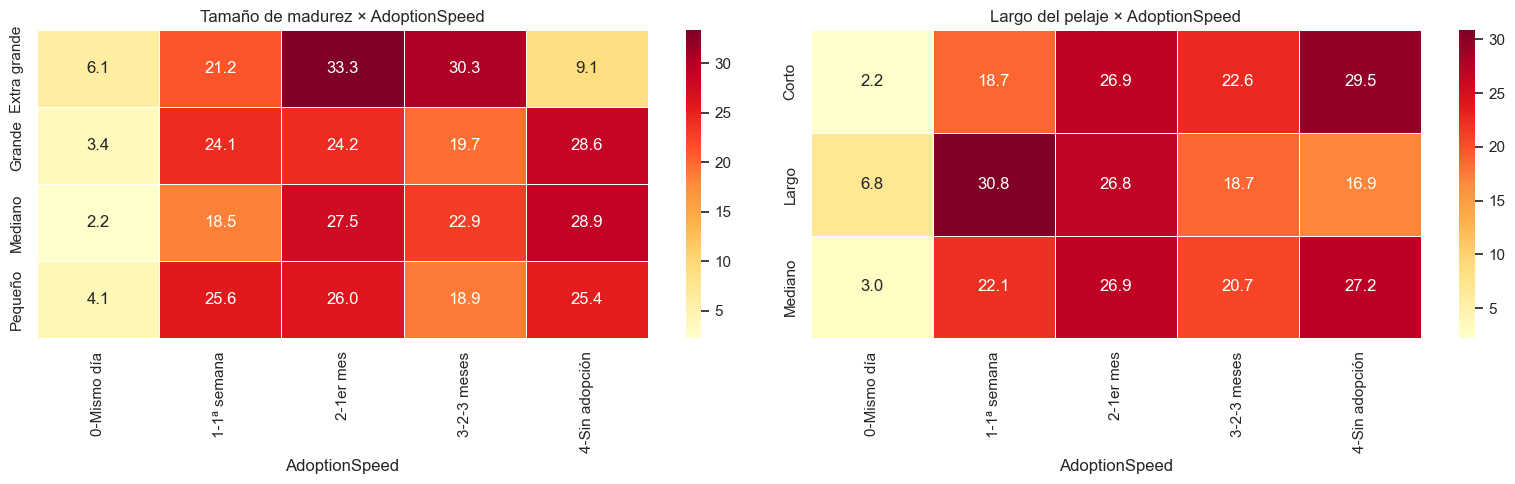

In [17]:
# ── MaturitySize como heatmap normalizado ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, col, title in zip(
    axes,
    ['MaturitySize_name', 'FurLength_name'],
    ['Tamaño de madurez × AdoptionSpeed', 'Largo del pelaje × AdoptionSpeed']
):
    pivot = pd.crosstab(train[col], train['AdoptionSpeed'], normalize='index') * 100
    pivot.columns = [SPEED_LABELS[c] for c in pivot.columns]
    sns.heatmap(
        pivot,
        annot=True,
        fmt='.1f',
        cmap='YlOrRd',
        ax=ax,
        linewidths=0.5
    )
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('AdoptionSpeed')
    ax.set_ylabel('')

plt.tight_layout()
plt.show()

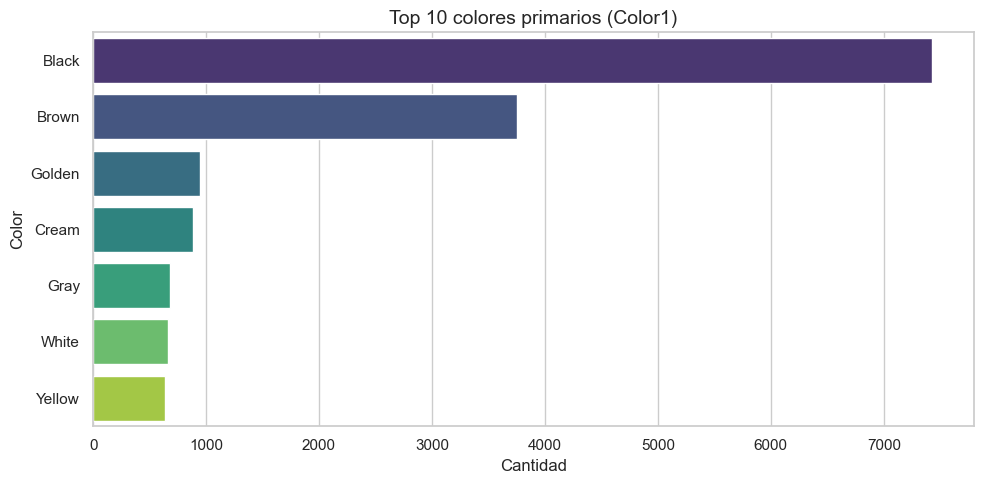

In [18]:
# ── Top colores (Color1_name) ──────────────────────────────────────────
top_colors = train['Color1_name'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=top_colors.values, y=top_colors.index, ax=ax, palette='viridis')
ax.set_title('Top 10 colores primarios (Color1)', fontsize=14)
ax.set_xlabel('Cantidad')
ax.set_ylabel('Color')
plt.tight_layout()
plt.show()

### Interpretación — Características Físicas

- **MaturitySize**: Las mascotas de tamaño mediano son las más comunes. No se observan diferencias marcadas en la velocidad de adopción según el tamaño.
- **FurLength**: El pelaje corto es el más frecuente. Las mascotas de pelo largo tienen una ligera tendencia a tardar más en ser adoptadas.
- **Color**: El negro y el marrón/castaño son los colores más frecuentes. Los colores más raros como el dorado o el crema pueden tener ligeras ventajas en adopción.

---
## Sección 6 — Estado de Salud

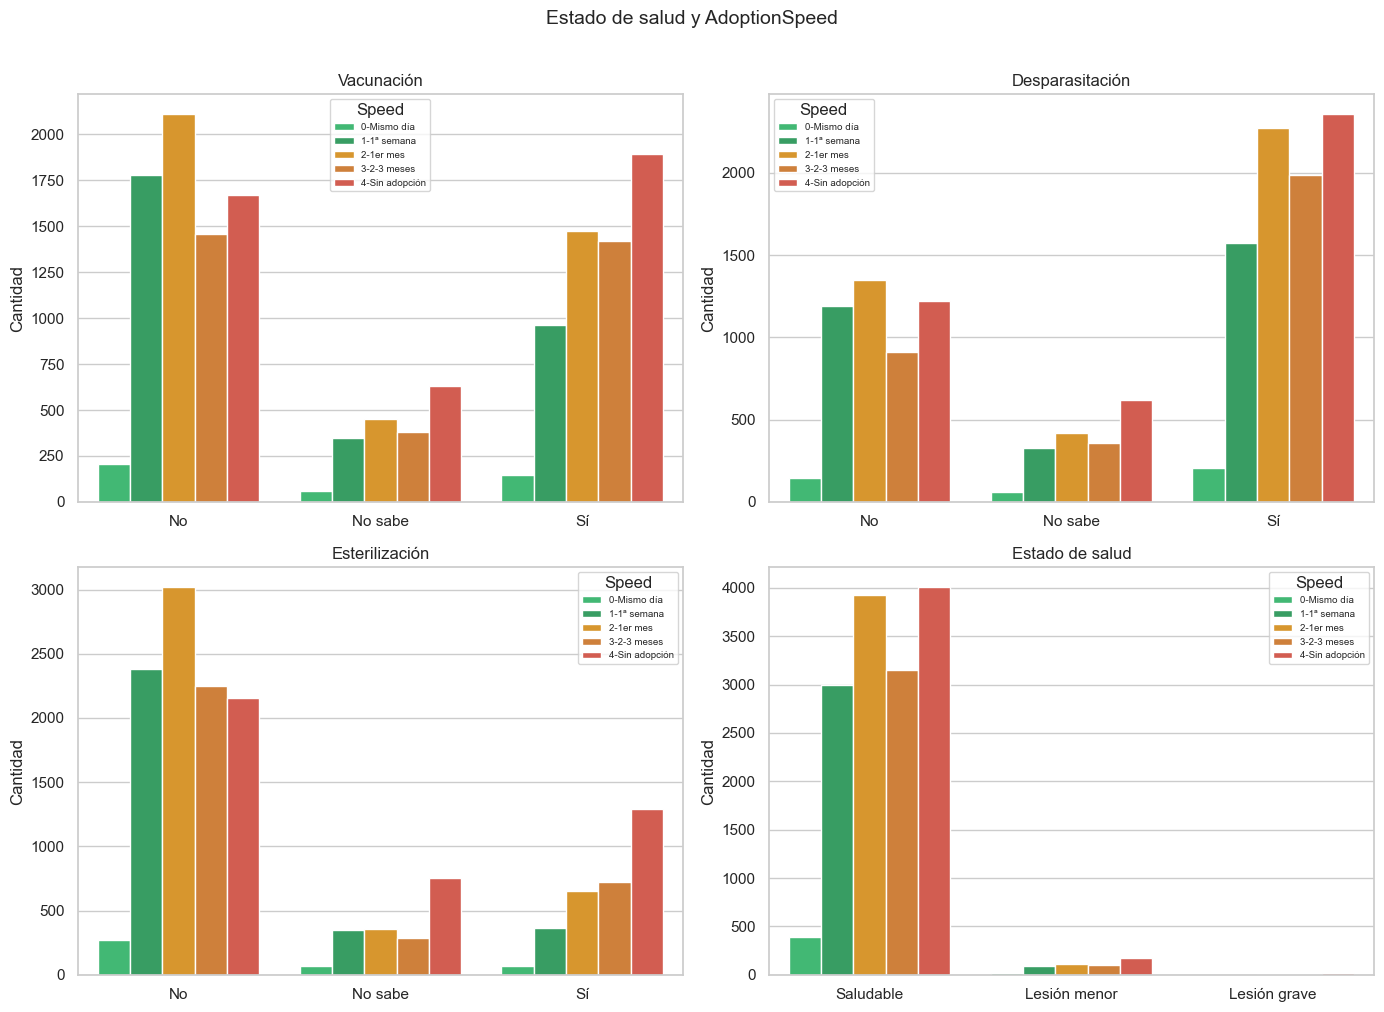

In [19]:
# ── Grid de countplots de salud ────────────────────────────────────────
health_vars = [
    ('Vaccinated_name', 'Vacunación'),
    ('Dewormed_name',   'Desparasitación'),
    ('Sterilized_name', 'Esterilización'),
    ('Health_name',     'Estado de salud'),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (col, title) in zip(axes, health_vars):
    sns.countplot(
        data=train,
        x=col,
        hue='AdoptionSpeed',
        palette=SPEED_COLORS,
        ax=ax
    )
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('')
    ax.set_ylabel('Cantidad')
    ax.legend(title='Speed', labels=[SPEED_LABELS[i] for i in range(5)], fontsize=7)

plt.suptitle('Estado de salud y AdoptionSpeed', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

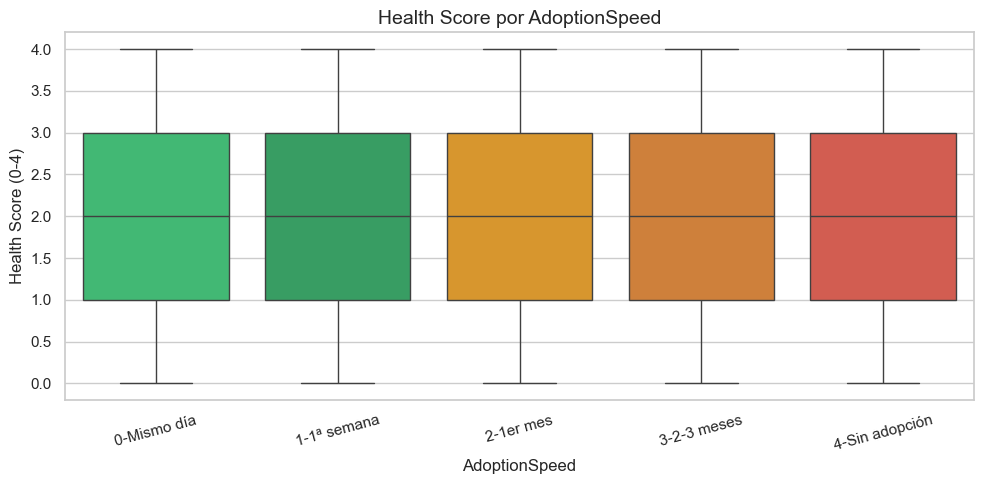

Health Score promedio por AdoptionSpeed:
AdoptionSpeed
0    1.983
1    1.909
2    2.063
3    2.233
4    2.277
Name: health_score, dtype: float64


In [20]:
# ── Boxplot de health_score por AdoptionSpeed ──────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(
    data=train,
    x='AdoptionSpeed',
    y='health_score',
    palette=SPEED_PALETTE,
    ax=ax
)
ax.set_title('Health Score por AdoptionSpeed', fontsize=14)
ax.set_xlabel('AdoptionSpeed')
ax.set_ylabel('Health Score (0-4)')
ax.set_xticklabels([SPEED_LABELS[i] for i in range(5)], rotation=15)
plt.tight_layout()
plt.show()

print('Health Score promedio por AdoptionSpeed:')
print(train.groupby('AdoptionSpeed')['health_score'].mean().round(3))

### Interpretación — Estado de Salud

- La mayoría de las mascotas están **vacunadas y desparasitadas**, pero la **esterilización** es menos común.
- El `health_score` promedio no muestra grandes diferencias entre clases de AdoptionSpeed, lo que sugiere que el estado de salud documentado no es el factor determinante principal para la velocidad de adopción.
- Sin embargo, las mascotas con **score 0** (ningún indicador positivo) tienden a concentrarse más en la clase 4 ("Sin adopción").

---
## Sección 7 — Media: Fotos y Videos

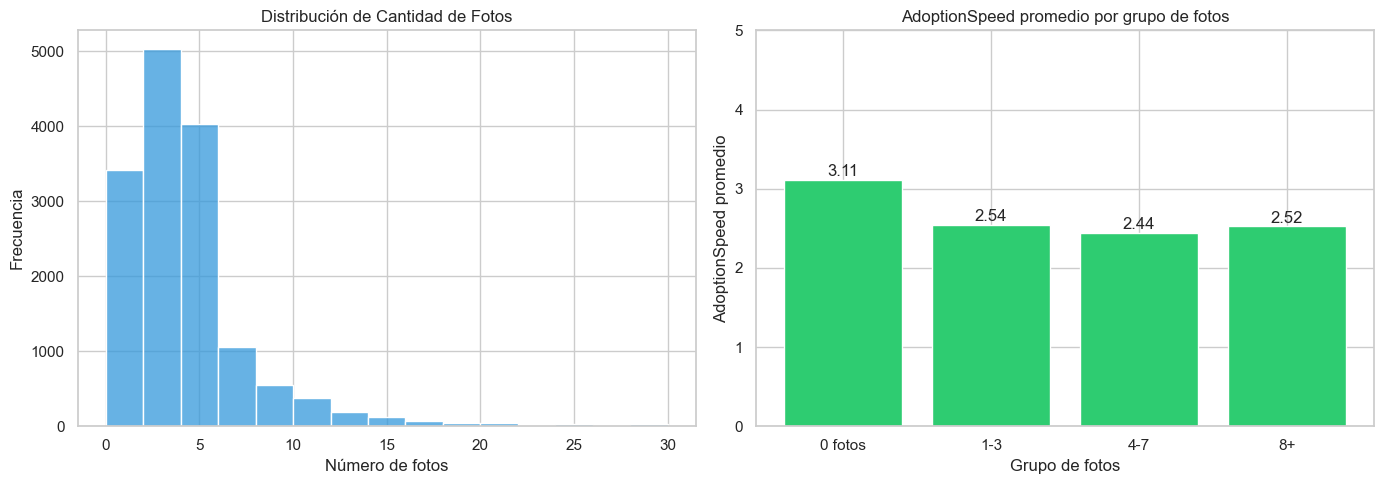

In [21]:
# ── Histograma de PhotoAmt ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(train['PhotoAmt'], bins=15, ax=axes[0], color='#3498db', edgecolor='white')
axes[0].set_title('Distribución de Cantidad de Fotos', fontsize=12)
axes[0].set_xlabel('Número de fotos')
axes[0].set_ylabel('Frecuencia')

# Barplot de AdoptionSpeed promedio por photo_group
photo_order = ['0 fotos', '1-3', '4-7', '8+']
photo_speed = train.groupby('photo_group')['AdoptionSpeed'].mean().reindex(photo_order)
axes[1].bar(photo_speed.index, photo_speed.values, color='#2ecc71', edgecolor='white')
axes[1].set_title('AdoptionSpeed promedio por grupo de fotos', fontsize=12)
axes[1].set_xlabel('Grupo de fotos')
axes[1].set_ylabel('AdoptionSpeed promedio')
axes[1].set_ylim(0, 5)
for i, v in enumerate(photo_speed.values):
    axes[1].text(i, v + 0.05, f'{v:.2f}', ha='center')

plt.tight_layout()
plt.show()

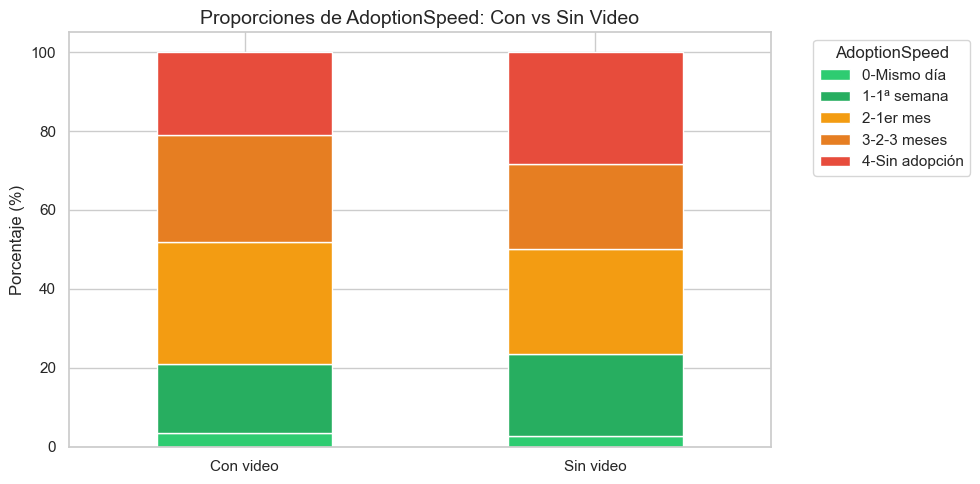

In [22]:
# ── Barplot VideoAmt vs AdoptionSpeed (proporciones) ──────────────────
train['tiene_video'] = (train['VideoAmt'] > 0).map({True: 'Con video', False: 'Sin video'})

video_cross = pd.crosstab(train['tiene_video'], train['AdoptionSpeed'], normalize='index') * 100

fig, ax = plt.subplots(figsize=(10, 5))
video_cross.plot(
    kind='bar',
    stacked=True,
    ax=ax,
    color=SPEED_PALETTE,
    edgecolor='white'
)
ax.set_title('Proporciones de AdoptionSpeed: Con vs Sin Video', fontsize=14)
ax.set_xlabel('')
ax.set_ylabel('Porcentaje (%)')
ax.legend([SPEED_LABELS[i] for i in range(5)], title='AdoptionSpeed', bbox_to_anchor=(1.05, 1))
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

### Interpretación — Fotos y Videos

- Las mascotas **sin fotos** tienen el mayor AdoptionSpeed promedio (más lento), lo que sugiere que incluir imágenes mejora las chances de adopción rápida.
- Existe un punto de rendimiento decreciente: de 1-3 a 4-7 fotos hay mejora, pero más de 8 fotos no necesariamente implica adopción más rápida.
- Los listings **con video** son muy pocos, por lo que no es posible sacar conclusiones sólidas, pero muestran una ligera tendencia positiva.

---
## Sección 8 — Fee (Costo de Adopción)

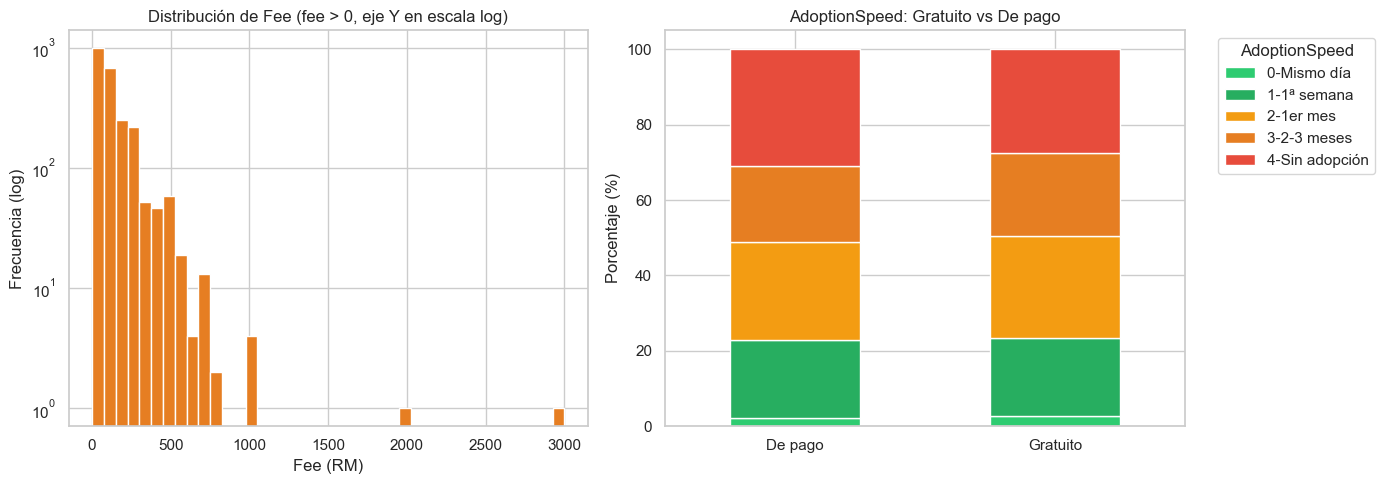

In [23]:
# ── Distribución del fee en escala log ────────────────────────────────
fee_pos = train[train['Fee'] > 0]['Fee']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma con log scale
axes[0].hist(fee_pos, bins=40, color='#e67e22', edgecolor='white', log=True)
axes[0].set_title('Distribución de Fee (fee > 0, eje Y en escala log)', fontsize=12)
axes[0].set_xlabel('Fee (RM)')
axes[0].set_ylabel('Frecuencia (log)')

# Gratuito vs pago por AdoptionSpeed
train['fee_tipo'] = (train['Fee'] > 0).map({True: 'De pago', False: 'Gratuito'})
fee_cross = pd.crosstab(train['fee_tipo'], train['AdoptionSpeed'], normalize='index') * 100
fee_cross.plot(
    kind='bar',
    stacked=True,
    ax=axes[1],
    color=SPEED_PALETTE,
    edgecolor='white'
)
axes[1].set_title('AdoptionSpeed: Gratuito vs De pago', fontsize=12)
axes[1].set_xlabel('')
axes[1].set_ylabel('Porcentaje (%)')
axes[1].legend([SPEED_LABELS[i] for i in range(5)], title='AdoptionSpeed', bbox_to_anchor=(1.05, 1))
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

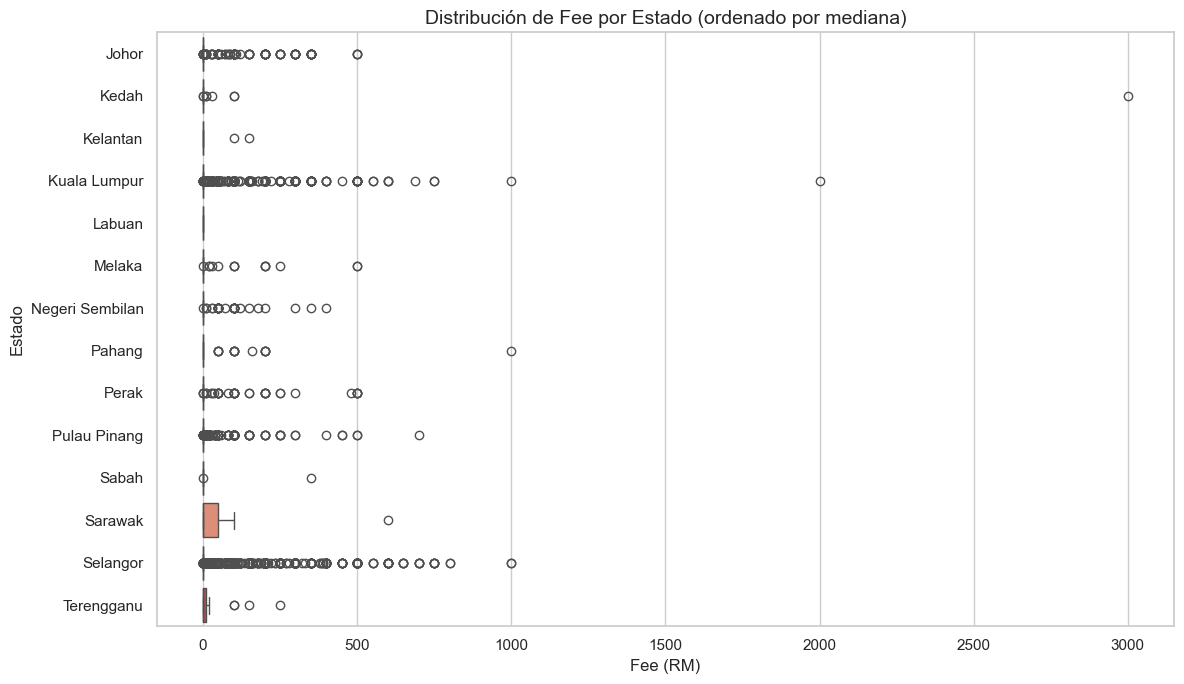

In [24]:
# ── Boxplot de Fee por State_name ─────────────────────────────────────
state_fee = train.groupby('State_name')['Fee'].median().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 7))
sns.boxplot(
    data=train,
    y='State_name',
    x='Fee',
    order=state_fee.index,
    palette='coolwarm',
    ax=ax
)
ax.set_title('Distribución de Fee por Estado (ordenado por mediana)', fontsize=14)
ax.set_xlabel('Fee (RM)')
ax.set_ylabel('Estado')
plt.tight_layout()
plt.show()

### Interpretación — Fee

- La gran mayoría de los listings son **gratuitos** (fee = 0).
- Los listings **de pago** tienden a tener una ligera mayor proporción en la clase 4 ("Sin adopción"), lo que sugiere que cobrar por la adopción puede reducir las chances de ser adoptado rápidamente.
- Existe variabilidad regional en el fee: algunos estados tienen medianas más altas que otros.
- Los valores extremos (hasta 3000 RM) son outliers que probablemente corresponden a mascotas de raza pura con pedigree.

---
## Sección 9 — Geografía: Estados de Malasia

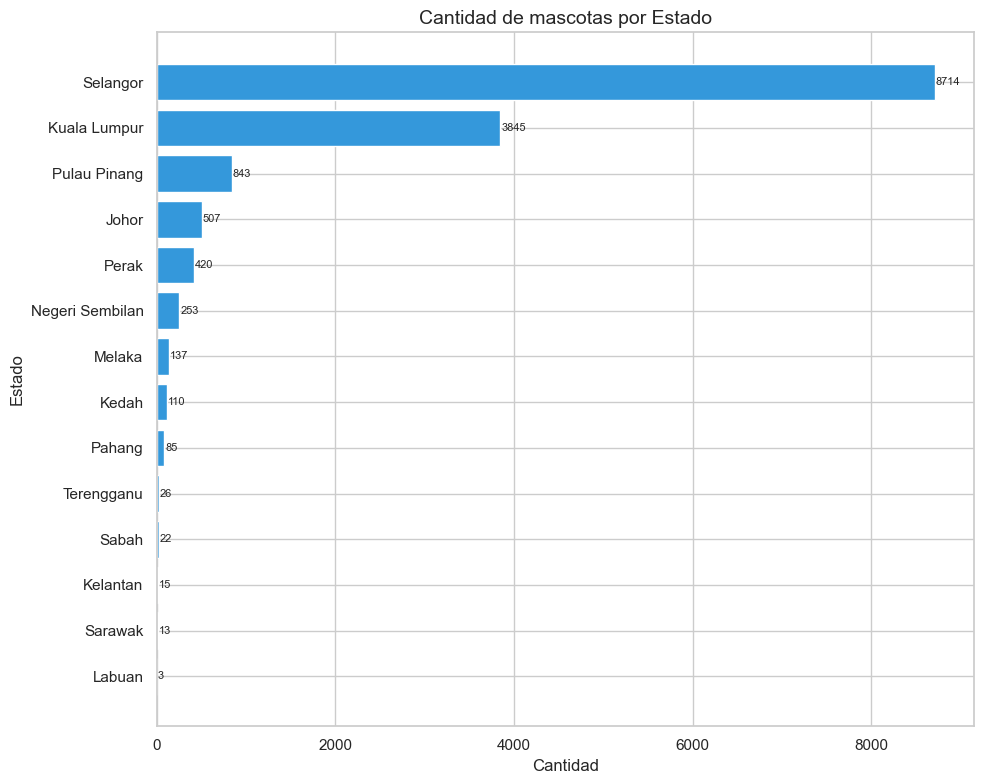

In [25]:
# ── Barplot horizontal de mascotas por estado ─────────────────────────
state_counts = train['State_name'].value_counts().sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(state_counts.index, state_counts.values, color='#3498db', edgecolor='white')
ax.set_title('Cantidad de mascotas por Estado', fontsize=14)
ax.set_xlabel('Cantidad')
ax.set_ylabel('Estado')
for i, v in enumerate(state_counts.values):
    ax.text(v + 10, i, str(v), va='center', fontsize=8)
plt.tight_layout()
plt.show()

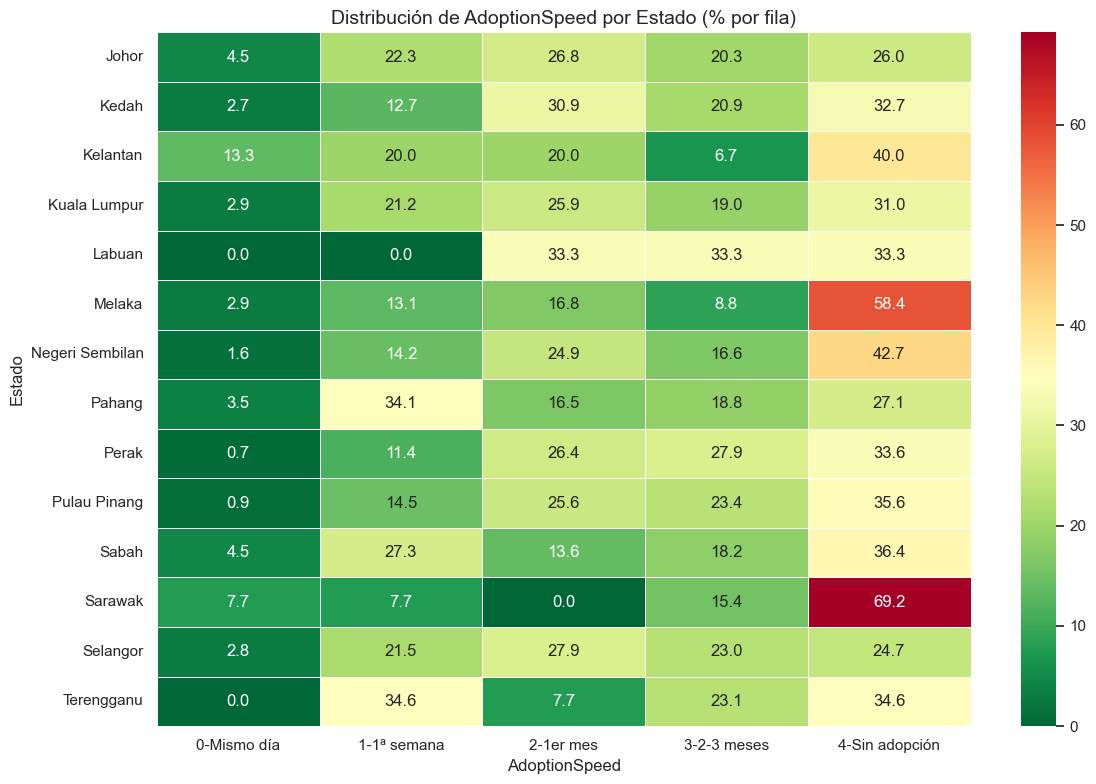

In [26]:
# ── Heatmap State_name × AdoptionSpeed (proporciones por estado) ───────
state_speed = pd.crosstab(train['State_name'], train['AdoptionSpeed'], normalize='index') * 100
state_speed.columns = [SPEED_LABELS[c] for c in state_speed.columns]

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(
    state_speed,
    annot=True,
    fmt='.1f',
    cmap='RdYlGn_r',
    linewidths=0.5,
    ax=ax
)
ax.set_title('Distribución de AdoptionSpeed por Estado (% por fila)', fontsize=14)
ax.set_xlabel('AdoptionSpeed')
ax.set_ylabel('Estado')
plt.tight_layout()
plt.show()

In [27]:
# ── Tabla de métricas por estado ───────────────────────────────────────
state_table = train.groupby('State_name').agg(
    N                = ('PetID', 'count'),
    Fee_promedio     = ('Fee', 'mean'),
    PhotoAmt_prom    = ('PhotoAmt', 'mean'),
    Speed_promedio   = ('AdoptionSpeed', 'mean'),
).round(2).sort_values('N', ascending=False)
state_table

,N,Fee_promedio,PhotoAmt_prom,Speed_promedio
State_name,,,,
Selangor,8714,22.64,4.03,2.45
Kuala Lumpur,3845,19.10,3.93,2.54
Pulau Pinang,843,16.40,3.13,2.78
Johor,507,28.64,3.36,2.41
Perak,420,13.75,3.65,2.82
Negeri Sembilan,253,14.23,3.68,2.85
Melaka,137,16.58,2.72,3.07
Kedah,110,29.56,3.32,2.68
Pahang,85,31.29,4.04,2.32


### Interpretación — Geografía

- **Selangor** y **Kuala Lumpur** concentran la mayor cantidad de listings, lo cual refleja la densidad poblacional de la región.
- Los estados con mayor AdoptionSpeed promedio (más lento) pueden indicar menor demanda local de adopciones.
- El fee promedio varía entre estados, reflejando diferencias socioeconómicas regionales.

---
## Sección 10 — Rescatistas

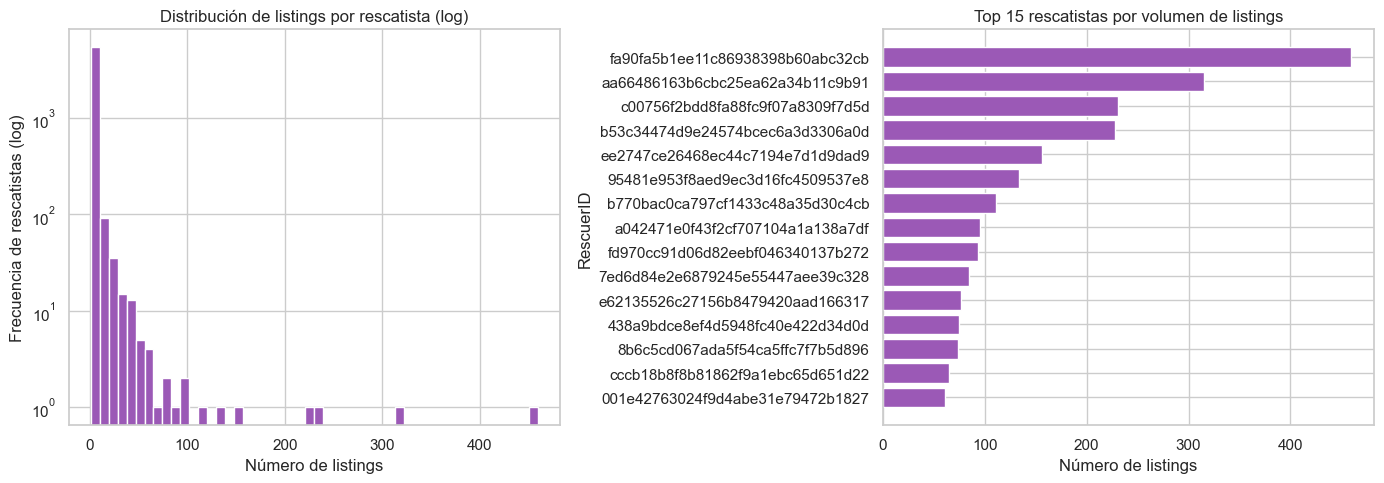

In [28]:
# ── Distribución de perfiles por rescatista ────────────────────────────
rescuer_counts = train['RescuerID'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma de frecuencia de frecuencias
axes[0].hist(rescuer_counts.values, bins=50, color='#9b59b6', edgecolor='white', log=True)
axes[0].set_title('Distribución de listings por rescatista (log)', fontsize=12)
axes[0].set_xlabel('Número de listings')
axes[0].set_ylabel('Frecuencia de rescatistas (log)')

# Top 15 rescatistas
top15 = rescuer_counts.head(15)
axes[1].barh(top15.index[::-1], top15.values[::-1], color='#9b59b6', edgecolor='white')
axes[1].set_title('Top 15 rescatistas por volumen de listings', fontsize=12)
axes[1].set_xlabel('Número de listings')
axes[1].set_ylabel('RescuerID')

plt.tight_layout()
plt.show()

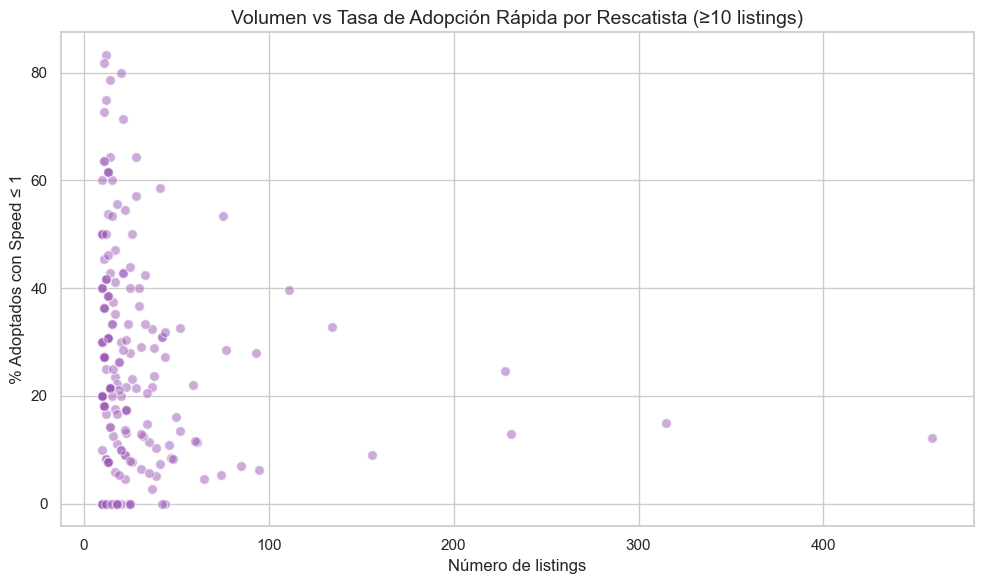

Rescatistas con >= 10 listings: 200


In [29]:
# ── Scatter: volumen vs tasa de adopción rápida (rescatistas con >= 10) ─
rescuer_stats = train.groupby('RescuerID').agg(
    volumen      = ('PetID', 'count'),
    tasa_rapida  = ('AdoptionSpeed', lambda x: (x <= 1).mean() * 100)
).reset_index()

rescuer_stats_10 = rescuer_stats[rescuer_stats['volumen'] >= 10]

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(
    rescuer_stats_10['volumen'],
    rescuer_stats_10['tasa_rapida'],
    alpha=0.5,
    color='#9b59b6',
    edgecolor='white',
    s=50
)
ax.set_title('Volumen vs Tasa de Adopción Rápida por Rescatista (≥10 listings)', fontsize=14)
ax.set_xlabel('Número de listings')
ax.set_ylabel('% Adoptados con Speed ≤ 1')
plt.tight_layout()
plt.show()

print(f'Rescatistas con >= 10 listings: {len(rescuer_stats_10)}')

### Interpretación — Rescatistas

- La distribución de listings por rescatista es **muy sesgada**: la mayoría tienen 1-3 listings, mientras que unos pocos tienen decenas o incluso más de cien.
- Los rescatistas con mayor volumen tienden a tener tasas de adopción rápida variables; no hay una correlación clara entre volumen y efectividad de adopción.
- Esto sugiere que la **identidad del rescatista** podría ser una feature útil para modelado (target encoding).

---
## Sección 11 — Nombre de la Mascota

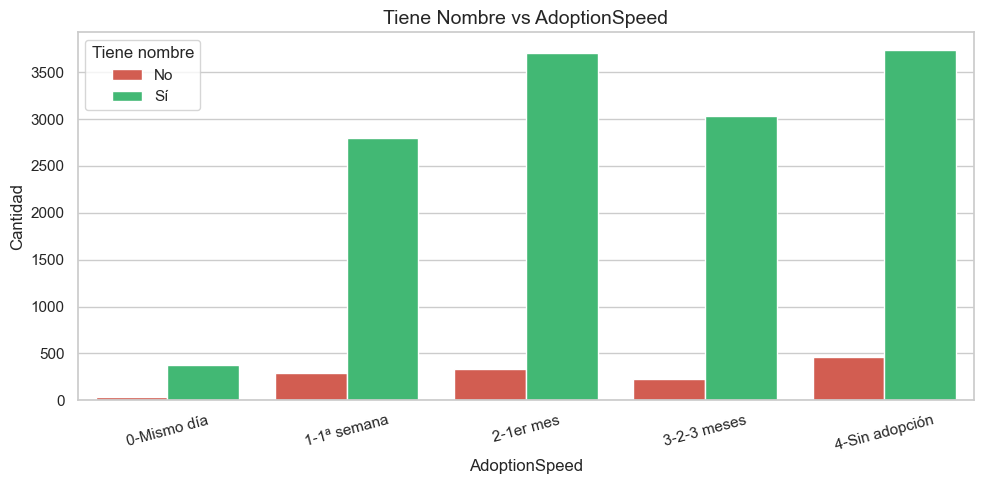

In [30]:
# ── Countplot Tiene_nombre vs AdoptionSpeed ────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
sns.countplot(
    data=train,
    x='AdoptionSpeed',
    hue='Tiene_nombre',
    palette={True: '#2ecc71', False: '#e74c3c'},
    ax=ax
)
ax.set_title('Tiene Nombre vs AdoptionSpeed', fontsize=14)
ax.set_xlabel('AdoptionSpeed')
ax.set_ylabel('Cantidad')
ax.set_xticklabels([SPEED_LABELS[i] for i in range(5)], rotation=15)
ax.legend(title='Tiene nombre', labels=['No', 'Sí'])
plt.tight_layout()
plt.show()

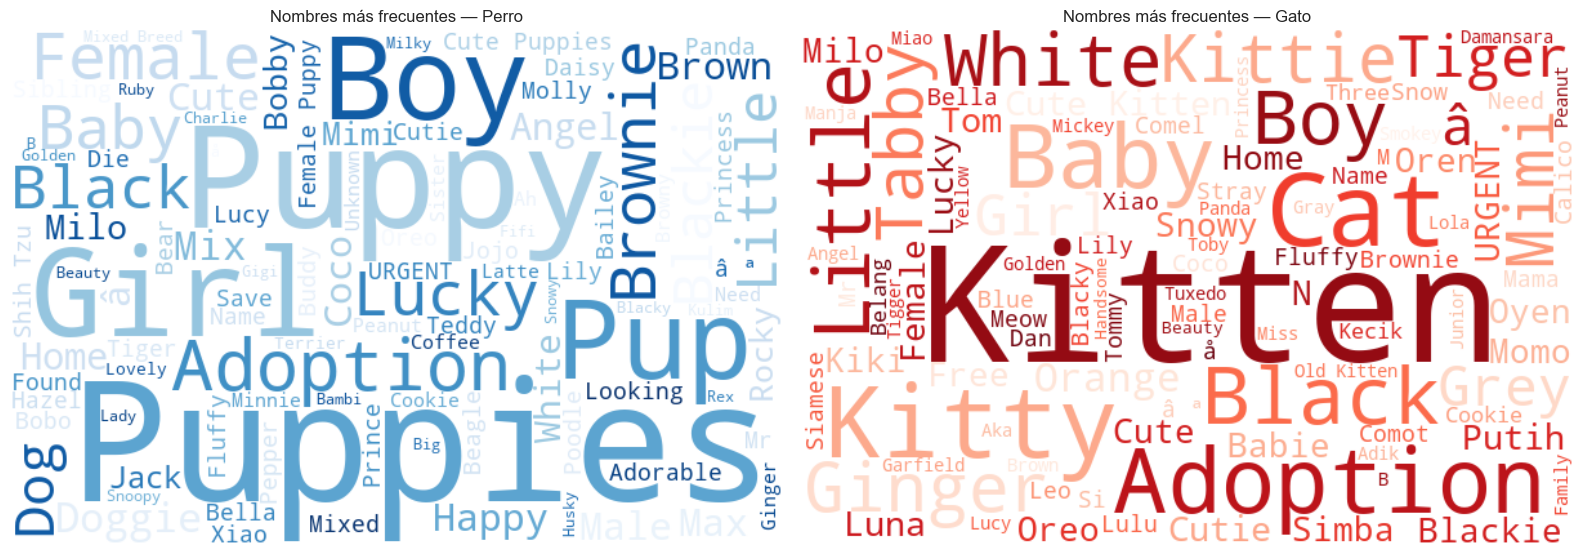

In [31]:
# ── WordCloud de nombres (perros y gatos) ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, tipo, color in zip(axes, ['Perro', 'Gato'], ['Blues', 'Reds']):
    names_corpus = ' '.join(
        train[
            (train['Type_name'] == tipo) &
            (train['Tiene_nombre'])
        ]['Name'].dropna().tolist()
    )
    if names_corpus.strip():
        wc = WordCloud(
            width=600, height=400,
            background_color='white',
            colormap=color,
            max_words=100
        ).generate(names_corpus)
        ax.imshow(wc, interpolation='bilinear')
    else:
        ax.text(0.5, 0.5, 'Sin datos', ha='center', va='center')
    ax.axis('off')
    ax.set_title(f'Nombres más frecuentes — {tipo}', fontsize=12)

plt.tight_layout()
plt.show()

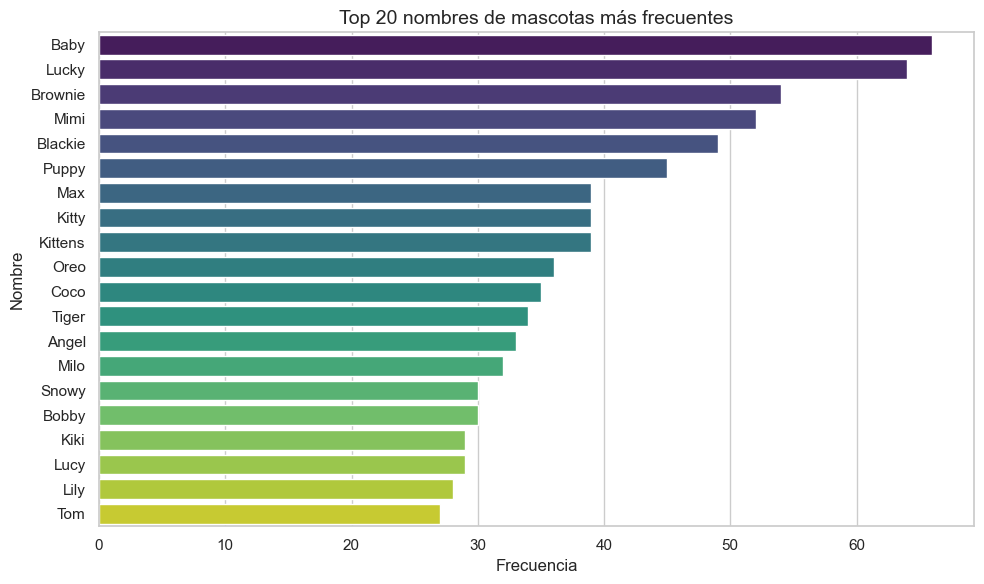

In [32]:
# ── Top 20 nombres más frecuentes ─────────────────────────────────────
top_names = (
    train[train['Tiene_nombre']]['Name']
    .value_counts()
    .head(20)
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=top_names.values, y=top_names.index, ax=ax, palette='viridis')
ax.set_title('Top 20 nombres de mascotas más frecuentes', fontsize=14)
ax.set_xlabel('Frecuencia')
ax.set_ylabel('Nombre')
plt.tight_layout()
plt.show()

### Interpretación — Nombre de la Mascota

- Las mascotas **con nombre** tienen una distribución de AdoptionSpeed ligeramente más favorable (más rápida) que las anónimas.
- Los nombres más populares son típicamente anglosajones o de origen malayo, siendo "Bella", "Max" y "Lucky" muy frecuentes tanto en perros como en gatos.
- La presencia de un nombre puede actuar como proxy de mayor cuidado y personalización del anuncio.

---
## Sección 12 — Descripción y Sentimiento

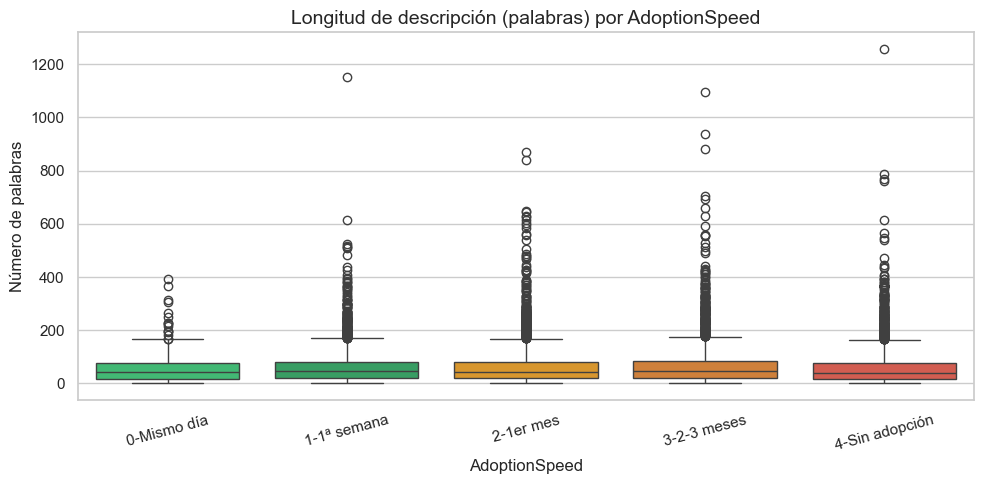

In [33]:
# ── Boxplot de Desc_len_words por AdoptionSpeed ────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(
    data=train,
    x='AdoptionSpeed',
    y='Desc_len_words',
    palette=SPEED_PALETTE,
    ax=ax
)
ax.set_title('Longitud de descripción (palabras) por AdoptionSpeed', fontsize=14)
ax.set_xlabel('AdoptionSpeed')
ax.set_ylabel('Número de palabras')
ax.set_xticklabels([SPEED_LABELS[i] for i in range(5)], rotation=15)
plt.tight_layout()
plt.show()

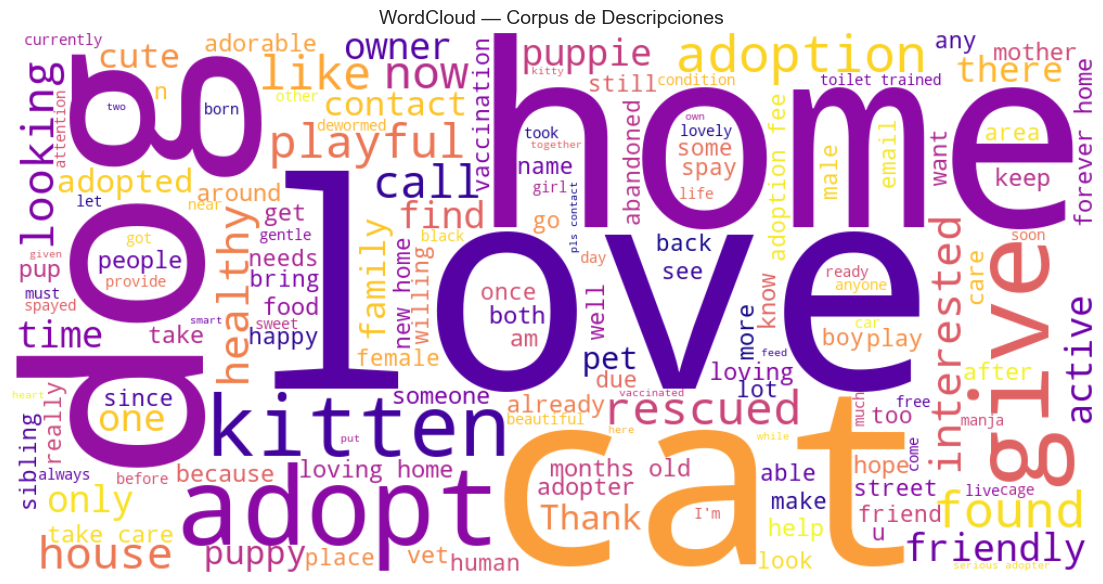

In [34]:
# ── WordCloud del corpus de descripciones ─────────────────────────────
# Stopwords básicas en inglés
basic_stopwords = {
    'the','a','an','and','or','but','in','on','at','to','for','of','with',
    'is','are','was','were','be','been','being','have','has','had','do',
    'does','did','will','would','could','should','may','might','shall',
    'it','its','he','she','they','we','you','i','me','him','her','them',
    'us','my','your','his','our','their','this','that','these','those',
    'very','also','not','no','so','if','by','from','as','up','out','about',
    'into','than','then','when','where','who','which','what','how','all',
    'can','please','need','good','will','just'
}

corpus = ' '.join(train['Description'].dropna().tolist())

fig, ax = plt.subplots(figsize=(14, 6))
wc = WordCloud(
    width=1000, height=500,
    background_color='white',
    stopwords=basic_stopwords,
    max_words=150,
    colormap='plasma'
).generate(corpus)

ax.imshow(wc, interpolation='bilinear')
ax.axis('off')
ax.set_title('WordCloud — Corpus de Descripciones', fontsize=14)
plt.tight_layout()
plt.show()

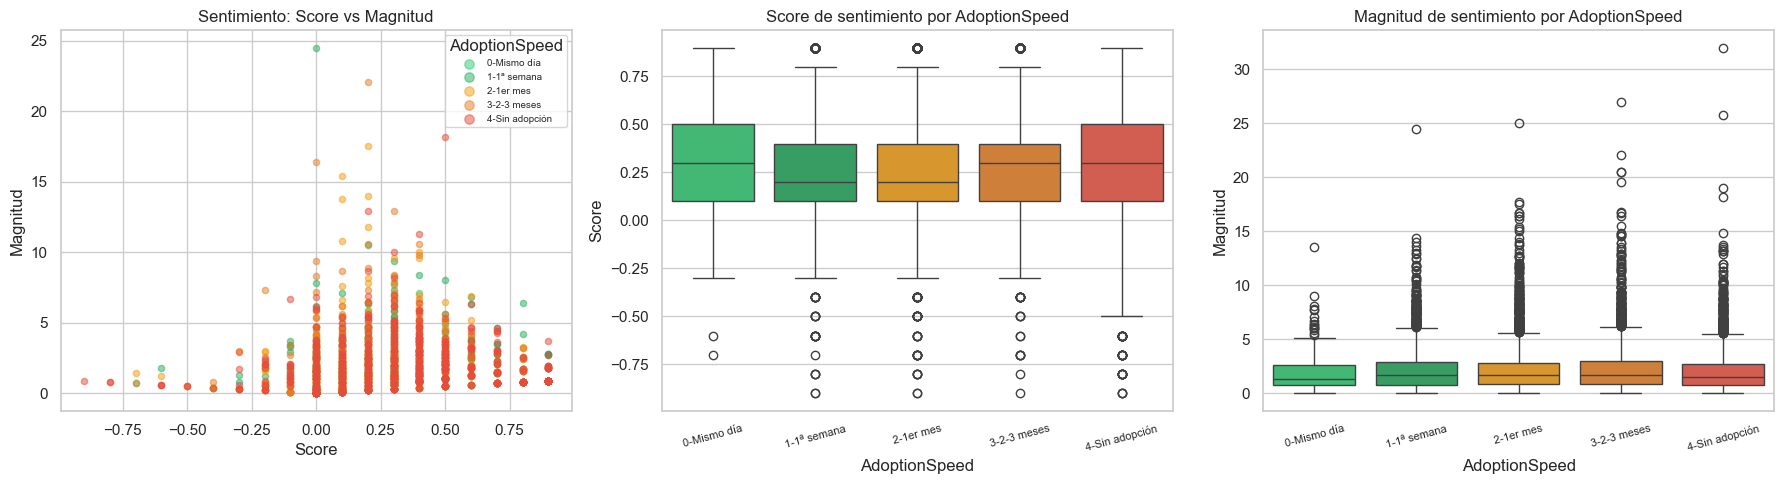

In [35]:
# ── Análisis de sentimiento ────────────────────────────────────────────
df_sent = train.dropna(subset=['sent_score', 'sent_magnitude']).copy()
sample_sent = df_sent.sample(min(2000, len(df_sent)), random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Scatter sent_score vs sent_magnitude coloreado por AdoptionSpeed
for speed in sorted(sample_sent['AdoptionSpeed'].unique()):
    mask = sample_sent['AdoptionSpeed'] == speed
    axes[0].scatter(
        sample_sent.loc[mask, 'sent_score'],
        sample_sent.loc[mask, 'sent_magnitude'],
        c=SPEED_COLORS[speed],
        alpha=0.5,
        s=20,
        label=SPEED_LABELS[speed]
    )
axes[0].set_title('Sentimiento: Score vs Magnitud', fontsize=12)
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Magnitud')
axes[0].legend(title='AdoptionSpeed', fontsize=7, markerscale=1.5)

# Boxplot sent_score por AdoptionSpeed
sns.boxplot(
    data=df_sent,
    x='AdoptionSpeed',
    y='sent_score',
    palette=SPEED_PALETTE,
    ax=axes[1]
)
axes[1].set_title('Score de sentimiento por AdoptionSpeed', fontsize=12)
axes[1].set_xlabel('AdoptionSpeed')
axes[1].set_ylabel('Score')
axes[1].set_xticklabels([SPEED_LABELS[i] for i in range(5)], rotation=15, fontsize=8)

# Boxplot sent_magnitude por AdoptionSpeed
sns.boxplot(
    data=df_sent,
    x='AdoptionSpeed',
    y='sent_magnitude',
    palette=SPEED_PALETTE,
    ax=axes[2]
)
axes[2].set_title('Magnitud de sentimiento por AdoptionSpeed', fontsize=12)
axes[2].set_xlabel('AdoptionSpeed')
axes[2].set_ylabel('Magnitud')
axes[2].set_xticklabels([SPEED_LABELS[i] for i in range(5)], rotation=15, fontsize=8)

plt.tight_layout()
plt.show()

### Interpretación — Descripción y Sentimiento

- Las mascotas con **descripciones más largas** tienden a distribuirse de manera más uniforme entre clases, mientras que los listings sin descripción (0 palabras) se concentran en clases de adopción lenta.
- El corpus de descripciones muestra palabras como "healthy", "friendly", "vaccinated", "looking", "home", lo que indica un lenguaje orientado a resaltar las virtudes de la mascota.
- El **score de sentimiento** es mayoritariamente positivo (distribución sesgada hacia valores > 0) en todas las clases, sin diferencias marcadas entre clases.
- La **magnitud** (intensidad del sentimiento) tampoco muestra una correlación clara con AdoptionSpeed, lo que sugiere que el tono del texto no es determinante por sí solo.

---
## Sección 13 — Listings Grupales

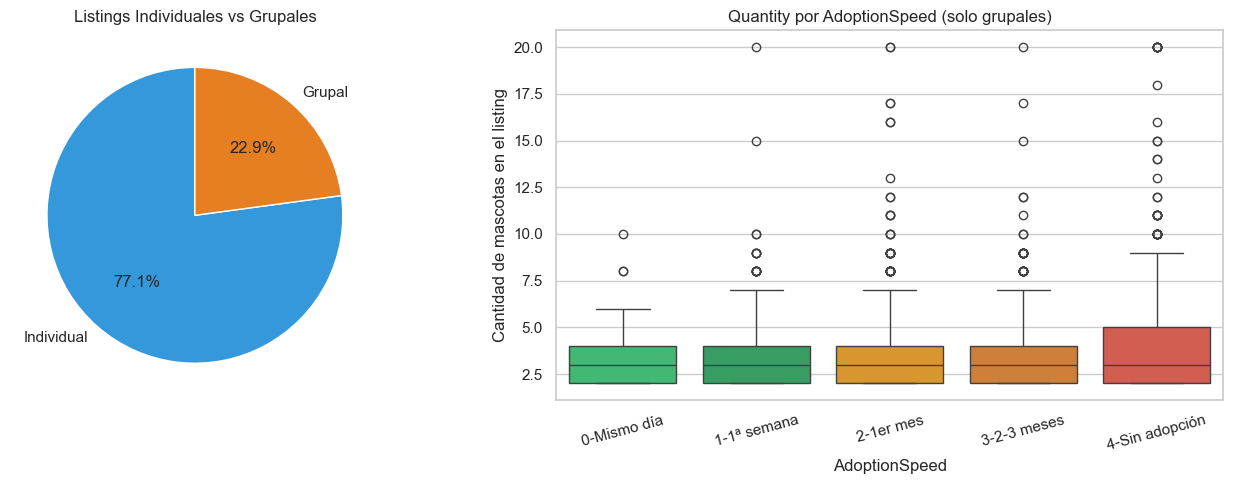

In [36]:
# ── Pie chart individual vs grupal ─────────────────────────────────────
train['listing_tipo'] = (train['Quantity'] == 1).map({True: 'Individual', False: 'Grupal'})
lt_counts = train['listing_tipo'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].pie(
    lt_counts.values,
    labels=lt_counts.index,
    autopct='%1.1f%%',
    colors=['#3498db', '#e67e22'],
    startangle=90
)
axes[0].set_title('Listings Individuales vs Grupales', fontsize=12)

# Boxplot Quantity por AdoptionSpeed (solo grupal)
df_grupal = train[train['Quantity'] > 1]
sns.boxplot(
    data=df_grupal,
    x='AdoptionSpeed',
    y='Quantity',
    palette=SPEED_PALETTE,
    ax=axes[1]
)
axes[1].set_title('Quantity por AdoptionSpeed (solo grupales)', fontsize=12)
axes[1].set_xlabel('AdoptionSpeed')
axes[1].set_ylabel('Cantidad de mascotas en el listing')
axes[1].set_xticklabels([SPEED_LABELS[i] for i in range(5)], rotation=15)

plt.tight_layout()
plt.show()

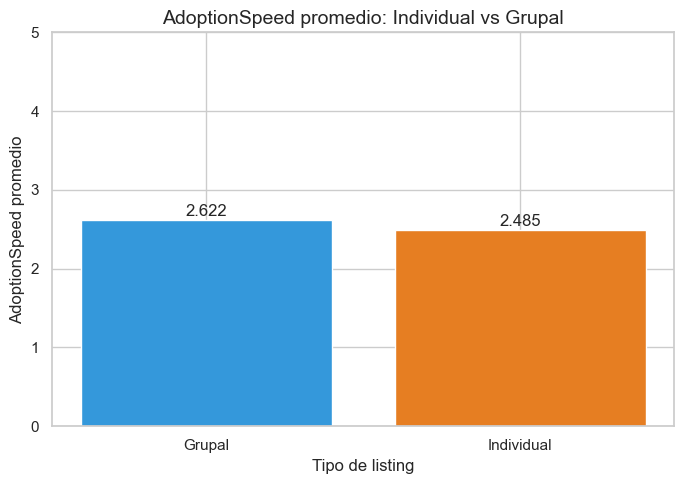

In [37]:
# ── AdoptionSpeed promedio: individual vs grupal ───────────────────────
speed_by_type = train.groupby('listing_tipo')['AdoptionSpeed'].mean().round(3)

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(speed_by_type.index, speed_by_type.values,
              color=['#3498db', '#e67e22'], edgecolor='white')
ax.set_title('AdoptionSpeed promedio: Individual vs Grupal', fontsize=14)
ax.set_xlabel('Tipo de listing')
ax.set_ylabel('AdoptionSpeed promedio')
ax.set_ylim(0, 5)
for bar, v in zip(bars, speed_by_type.values):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.05, f'{v:.3f}', ha='center')
plt.tight_layout()
plt.show()

### Interpretación — Listings Grupales

- La inmensa mayoría de los listings son **individuales** (Quantity == 1).
- Los listings grupales (camadas, lotes) tienden a tener un AdoptionSpeed promedio ligeramente diferente, lo que podría relacionarse con la mayor dificultad de encontrar adoptantes dispuestos a llevarse múltiples mascotas.
- La variable `Quantity` tiene outliers significativos, con algunos listings de hasta 20+ mascotas.

---
## Sección 14 — Análisis Multivariado

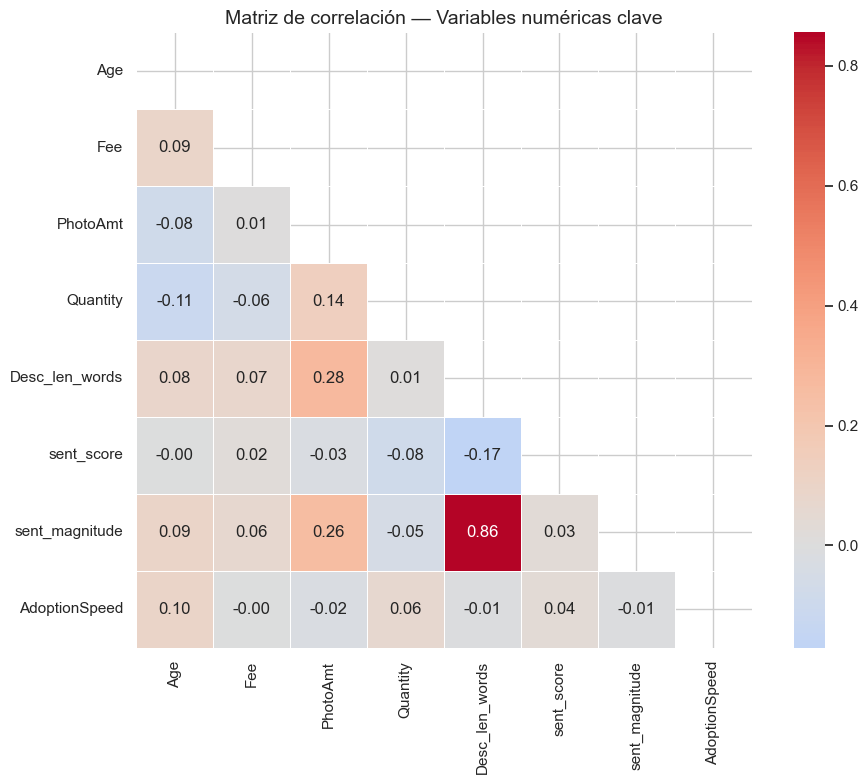

In [38]:
# ── Matriz de correlación ──────────────────────────────────────────────
numeric_vars = ['Age', 'Fee', 'PhotoAmt', 'Quantity', 'Desc_len_words',
                'sent_score', 'sent_magnitude', 'AdoptionSpeed']

corr_matrix = train[numeric_vars].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    mask=mask,
    ax=ax,
    linewidths=0.5,
    square=True
)
ax.set_title('Matriz de correlación — Variables numéricas clave', fontsize=14)
plt.tight_layout()
plt.show()

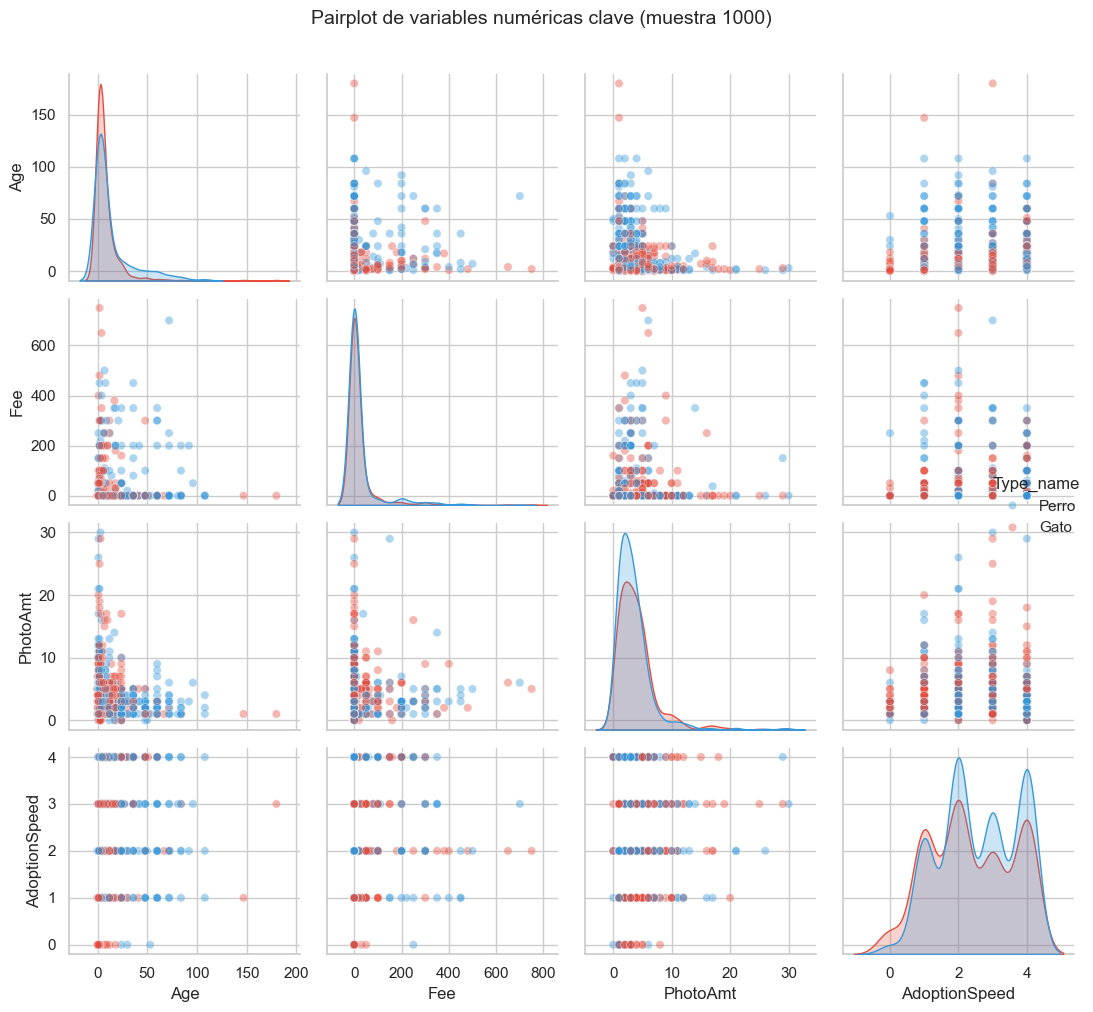

In [39]:
# ── Pairplot: Age, Fee, PhotoAmt, AdoptionSpeed coloreado por Type ────
sample_pp = train[['Age', 'Fee', 'PhotoAmt', 'AdoptionSpeed', 'Type_name']].dropna().sample(1000, random_state=42)

pp = sns.pairplot(
    sample_pp,
    hue='Type_name',
    palette={'Perro': '#3498db', 'Gato': '#e74c3c'},
    plot_kws={'alpha': 0.4},
    diag_kind='kde'
)
pp.fig.suptitle('Pairplot de variables numéricas clave (muestra 1000)', y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

### Interpretación — Análisis Multivariado

- Las correlaciones con **AdoptionSpeed** son en general bajas, lo que confirma que el problema es complejo y multifactorial.
- La correlación más notable con AdoptionSpeed es **Age** (positiva: mascotas más viejas tardan más en adoptarse) y **PhotoAmt** (negativa: más fotos, adopción más rápida).
- **sent_score** y **sent_magnitude** tienen correlación muy baja con AdoptionSpeed.
- El pairplot muestra que perros y gatos tienen distribuciones similares pero con algunas diferencias notables en Age y Fee.

---
## Sección 15 — Síntesis de Hallazgos

### Tabla Resumen de Hallazgos Principales

| Variable | Hallazgo principal | Impacto sobre AdoptionSpeed |
|---|---|---|
| **Type** | Perros se adoptan ligeramente más rápido | Bajo-moderado |
| **Age** | Mascotas más jóvenes se adoptan más rápido | Moderado |
| **PhotoAmt** | Más fotos → adopción más rápida (hasta 4-7) | Moderado |
| **Fee** | Listings gratuitos → mayor tasa de adopción rápida | Moderado |
| **Tiene_nombre** | Mascotas con nombre → ligera ventaja | Bajo |
| **Desc_len_words** | Descripciones más largas: cierta ventaja | Bajo |
| **State** | Selangor/KL dominan en volumen; variabilidad regional | Bajo-moderado |
| **Health/Vaccinated** | Mascotas saludables y vacunadas tienen ligera ventaja | Bajo |
| **Breed** | Razas mixtas y populares se adoptan con frecuencia | Bajo |
| **Sentimiento** | Score/magnitud no discriminan bien las clases | Muy bajo |
| **Quantity** | Listings grupales ligeramente más lentos | Bajo |
| **RescuerID** | Alta variabilidad entre rescatistas | Moderado (como feature) |

### Conclusión narrativa

El análisis exploratorio del dataset **PetFinder Adoption Prediction** revela que la velocidad de adopción de mascotas en Malasia es un fenómeno **multifactorial** con baja correlación lineal entre las variables individuales y el target.

Los factores más relevantes observados son la **edad de la mascota** (las crías se adoptan mucho más rápido), la **cantidad de fotos** (la calidad del anuncio importa), si la adopción es **gratuita** (la barrera económica es real) y el **tipo de animal** (perros con ligera ventaja sobre gatos).

La variable target presenta un **desequilibrio significativo**, con casi un 28% de mascotas sin adoptar y solo un 2.7% adoptadas el mismo día. Esto obliga a utilizar métricas y técnicas de modelado que manejen apropiadamente el desbalance de clases.

El **análisis de texto y sentimiento** sugiere que la calidad de la descripción puede aportar señal indirectamente (a través de la longitud), pero el sentimiento en sí no es discriminador potente. Las features de **identidad del rescatista** y la **ubicación geográfica** merecen mayor exploración mediante técnicas de encoding supervisado en la fase de modelado.